# 1. Analyse Exploratoire et Preparation des Donnees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1.1 Chargement du Dataset

In [2]:
df = pd.read_csv('../data/raw/conversion_data_train.csv')

print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
display(df.head())

Dimensions du dataset : 284580 lignes, 6 colonnes.


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


## 1.2 Audit des donnees
Verification des types, valeurs nulles et anomalies.

In [ ]:
# Verification des types et des valeurs nulles
df.info()

print("-" * 30)
print("Pourcentage de valeurs manquantes par colonne :")
print(df.isnull().mean() * 100)

In [ ]:
# Statistiques descriptives
# Detection des anomalies (ex: age negatif ou > 100)
df.describe()

## 1.3 Analyse de la variable cible
Distribution de `converted`. Le desequilibre des classes impose d'utiliser le F1-Score plutot que l'Accuracy.

In [ ]:
conversion_rate = df['converted'].value_counts(normalize=True) * 100

print(f"Taux de non-conversion (0) : {conversion_rate[0]:.2f}%")
print(f"Taux de conversion (1)     : {conversion_rate[1]:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(
    x='converted', hue='converted',
    legend=False, data=df, palette='viridis'
)
plt.title("Distribution de la variable cible 'Converted'")
plt.show()

## 1.4 Analyse des correlations et comportements

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    x='country', y='converted', hue='country',
    legend=False, data=df, ax=axes[0], palette='magma'
)
axes[0].set_title("Taux de conversion par Pays")

sns.barplot(
    x='source', y='converted', hue='source',
    legend=False, data=df, ax=axes[1], palette='magma'
)
axes[1].set_title("Taux de conversion par Source de trafic")

plt.show()

**Observations :**
* Disparites de conversion selon les pays (China et US plus eleves).
* La source de trafic a un impact limite.

In [ ]:
plt.figure(figsize=(12, 5))
sns.histplot(
    data=df, x='age', hue='converted',
    multiple="stack", bins=30, palette='viridis'
)
plt.title("Distribution des ages selon la conversion")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(
    x='converted', y='total_pages_visited',
    hue='converted', legend=False,
    data=df, palette='viridis'
)
plt.title("Impact du nombre de pages vues sur la conversion")
plt.show()

## 1.5 Nettoyage des donnees
Suppression des valeurs aberrantes : age max = 123 ans (probablement des erreurs de saisie).

In [8]:
print(f"Lignes avant nettoyage : {len(df)}")
df = df[df['age'] < 100]
print(f"Lignes apres nettoyage : {len(df)}")

Lignes avant nettoyage : 284580
Lignes apres nettoyage : 284578


# 2. Modelisation

## 2.1 Preprocessing
- One-Hot Encoding des variables categorielles (`country`, `source`)
- Split Train/Test stratifie 80/20
- StandardScaler pour la normalisation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separation Target / Features
target_name = 'converted'
X = df.drop(target_name, axis=1)
y = df[target_name]

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Split Train/Test stratifie (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train : {X_train_scaled.shape}, Test : {X_test_scaled.shape}")

## 2.2 Baseline : Regression Logistique

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

model_lr = LogisticRegression(
    class_weight='balanced', random_state=42
)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

print("Classification Report (Baseline) :")
print(classification_report(y_test, y_pred_lr))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=ax, cmap='Blues'
)
ax.set_title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

print(f"\nF1-Score (classe 1) : {f1_score(y_test, y_pred_lr):.4f}")

## 2.3 Random Forest
Ensemble d'arbres de decision par bagging. `class_weight='balanced'` pour gerer le desequilibre.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

print("Classification Report (Random Forest) :")
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=ax, cmap='Oranges'
)
ax.set_title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

print(f"\nF1-Score (classe 1) : {f1_score(y_test, y_pred_rf):.4f}")

## 2.4 XGBoost
Gradient boosting, performant sur les donnees tabulaires.

In [ ]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42)
model_xgb.fit(X_train_scaled, y_train)

y_pred_xgb = model_xgb.predict(X_test_scaled)

print("Classification Report (XGBoost) :")
print(classification_report(y_test, y_pred_xgb))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, ax=ax, cmap='Greens'
)
ax.set_title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

print(f"\nF1-Score (classe 1) : {f1_score(y_test, y_pred_xgb):.4f}")

## 2.5 Optimisation des Hyperparametres (GridSearchCV)
Recherche exhaustive sur une grille de parametres, optimisant le F1-Score en cross-validation 3-fold.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nMeilleurs hyperparametres : {grid_search.best_params_}")
print(f"Meilleur F1-Score (CV) : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("\nClassification Report (XGBoost Optimise) :")
print(classification_report(y_test, y_pred_best))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, ax=ax, cmap='RdYlGn'
)
ax.set_title("Confusion Matrix - XGBoost Optimise (GridSearchCV)")
plt.tight_layout()
plt.show()

print(f"\nF1-Score (classe 1) : {f1_score(y_test, y_pred_best):.4f}")

## 2.6 Comparaison des Modeles (Cross-Validation)
Evaluation robuste de tous les modeles en cross-validation 3-fold.

In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validation F1 pour chaque modele (cv=3)
models = {
    'Logistic Regression': model_lr,
    'Random Forest': model_rf,
    'XGBoost (Defaut)': model_xgb,
    'XGBoost (Optimise)': best_model
}

results = []
for name, model in models.items():
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=3, scoring='f1', n_jobs=-1
    )
    test_f1 = f1_score(y_test, model.predict(X_test_scaled))
    results.append({
        'Modele': name,
        'F1 CV (Mean)': round(cv_scores.mean(), 4),
        'F1 CV (Std)': round(cv_scores.std(), 4),
        'F1 Test': round(test_f1, 4)
    })

comparison_df = pd.DataFrame(results)
print("Comparaison des modeles :")
display(comparison_df)

## 3. Feature Importance
Variables les plus determinantes selon le meilleur modele.

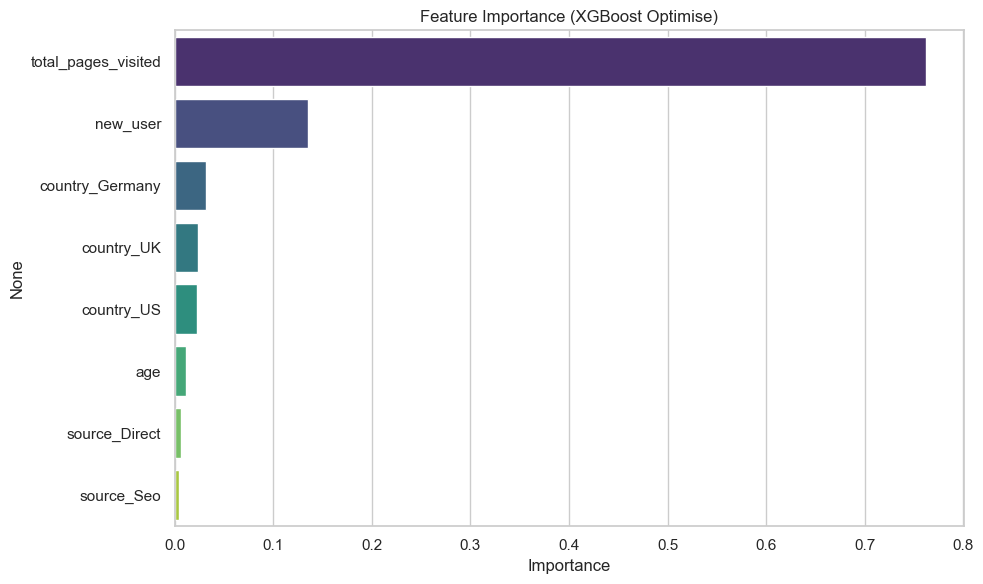

In [15]:
feature_names = X.columns
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances[indices], y=feature_names[indices],
    hue=feature_names[indices], legend=False, palette="viridis"
)
plt.title("Feature Importance (XGBoost Optimise)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 4. Prediction sur les donnees de test (Submission)
Application du meilleur modele sur `conversion_data_test.csv` avec le meme preprocessing.

In [ ]:
# Chargement des donnees de test
df_final = pd.read_csv('../data/raw/conversion_data_test.csv')
print(f"Donnees finales chargees : {df_final.shape}")

# Preprocessing identique a l'entrainement
X_final = pd.get_dummies(df_final, drop_first=True)

# Alignement des colonnes
features_train = X.columns
X_final = X_final.reindex(columns=features_train, fill_value=0)

# Normalisation avec le scaler deja entraine
X_final_scaled = scaler.transform(X_final)

# Predictions avec le meilleur modele
y_final_pred = best_model.predict(X_final_scaled)

# Fichier de soumission
submission = pd.DataFrame({'converted': y_final_pred})
submission.to_csv('../data/processed/submission.csv', index=False)

print("Fichier 'submission.csv' genere.")
print(f"Distribution des predictions :")
print(pd.Series(y_final_pred).value_counts())

# 5. Conclusion et Recommandations

## Bilan
| Modele | F1 (CV) | F1 (Test) |
|--------|---------|-----------|
| Logistic Regression | 0.5111 | 0.5118 |
| Random Forest | 0.5754 | 0.5761 |
| XGBoost (defaut) | 0.7561 | 0.7544 |
| **XGBoost (optimise)** | **0.7650** | **0.7591** |

## Leviers d'action
1. **total_pages_visited** : predicteur dominant. Au-dela de 12-15 pages, conversion quasi-certaine. Inciter la navigation (liens internes, suggestions).
2. **age** : les 18-30 ans convertissent mieux. Cibler les campagnes sur cette tranche.
3. **new_user** : les utilisateurs recurrents convertissent mieux. Mettre en place du retargeting.
4. **country** : disparites geographiques. Adapter le contenu par region.